# practical 

In [346]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [347]:
df=pd.read_excel('mock_dataset.xlsx')

In [348]:
df.head()

,id,product,price,brand_model,discount,Amazon,Flipkart,rating,stock,seller_city,warranty
0,1,keyboard,Rs.70000,dell-d11,flat ten,0,1,3.8,Y,Noida,OneYr
1,2,mobile,80k,logitech K120,none,0,1,NaN,0,pune,NaN
2,3,headphone,100$,classmate,flat ten,1,0,4.5,1,Bangalore,1 year
3,4,accessories,"rs1,299",dell-d11,NaN,1,0,3,Y,Delhi,OneYr
4,5,books,899rs/-,classmate,NaN,0,0,4.5,1,Noida,OneYr


In [349]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           1000 non-null   int64 
 1   product      1000 non-null   object
 2   price        1000 non-null   object
 3   brand_model  893 non-null    object
 4   discount     881 non-null    object
 5   Amazon       1000 non-null   int64 
 6   Flipkart     1000 non-null   int64 
 7   rating       868 non-null    object
 8   stock        1000 non-null   object
 9   seller_city  1000 non-null   object
 10  warranty     683 non-null    object
dtypes: int64(3), object(8)
memory usage: 86.1+ KB


In [350]:
df.columns

Index(['id', 'product', 'price', 'brand_model', 'discount', 'Amazon',
       'Flipkart', 'rating', 'stock', 'seller_city', 'warranty'],
      dtype='object')

In [351]:
df.isnull().sum() # finding the null values

id               0
product          0
price            0
brand_model    107
discount       119
Amazon           0
Flipkart         0
rating         132
stock            0
seller_city      0
warranty       317
dtype: int64

In [352]:
for i in df.columns:
    if df[i].isnull().any():
        print(i, df[i].isnull().sum(), sep = ' ')

brand_model 107
discount 119
rating 132
warranty 317


In [353]:
df['brand_model'].dropna() #cleaning brand model

0           dell-d11
1      logitech K120
2          classmate
3           dell-d11
4          classmate
           ...      
995     Samsung S-12
996         boAT-B19
997       lenovo L11
998        classmate
999    logitech K120
Name: brand_model, Length: 893, dtype: object

In [354]:
df['brand_model']=df['brand_model'].dropna() # dropped nulls from brand model

In [355]:
df['brand_model'].unique()

array(['dell-d11', 'logitech K120', 'classmate', 'acer Aspire 5',
       'vivo,V1.', nan, 'apple-13', 'lenovo tab M10', 'samsung S12',
       'boAT-B19', 'HP-H01', 'samsung,s12', 'JBL_450BT', 'Mi-Cable',
       'Samsung S-12', 'boAT-B11', 'lenovo L11', 'boat b11', 'flat 10%',
       'flat 20%', 'flat ten', 'upto 30%', 'flat 15%'], dtype=object)

In [356]:
df['brand_model'] = df['brand_model'].str.title().str.strip()

In [357]:
df.loc[(df['brand_model']=='Samsung,S12') | (df['brand_model']=='Samsung S-12'), 'brand_model']

18      Samsung,S12
20      Samsung,S12
31     Samsung S-12
58     Samsung S-12
95      Samsung,S12
           ...     
953     Samsung,S12
957     Samsung,S12
962     Samsung,S12
981    Samsung S-12
995    Samsung S-12
Name: brand_model, Length: 84, dtype: object

In [358]:
df['brand_model'] = df['brand_model'].replace({'Samsung,S12':'Samsung S12','Samsung S-12':'Samsung S12'})
df['brand_model'] = df['brand_model'].replace({'Boat B11':'Boat-B11','Vivo,V1.':'Vivo V1'})

In [359]:
df['brand_model'].unique()

array(['Dell-D11', 'Logitech K120', 'Classmate', 'Acer Aspire 5',
       'Vivo V1', nan, 'Apple-13', 'Lenovo Tab M10', 'Samsung S12',
       'Boat-B19', 'Hp-H01', 'Jbl_450Bt', 'Mi-Cable', 'Boat-B11',
       'Lenovo L11', 'Flat 10%', 'Flat 20%', 'Flat Ten', 'Upto 30%',
       'Flat 15%'], dtype=object)

In [360]:
s = df['brand_model'].mode()[0]
df['brand_model'] = df['brand_model'].fillna(s)

In [361]:
df['brand_model'] = df['brand_model'].replace({'Flat 10%':'Samsung S12', 'Flat 20%':'Samsung S12', 'Flat Ten':'Samsung S12', 'Upto 30%':'Samsung S12', 'Flat 15%':'Samsung S12'})

In [362]:
df['brand_model']

0           Dell-D11
1      Logitech K120
2          Classmate
3           Dell-D11
4          Classmate
           ...      
995      Samsung S12
996         Boat-B19
997       Lenovo L11
998        Classmate
999    Logitech K120
Name: brand_model, Length: 1000, dtype: object

In [363]:
df['brand_model'].unique()

array(['Dell-D11', 'Logitech K120', 'Classmate', 'Acer Aspire 5',
       'Vivo V1', 'Samsung S12', 'Apple-13', 'Lenovo Tab M10', 'Boat-B19',
       'Hp-H01', 'Jbl_450Bt', 'Mi-Cable', 'Boat-B11', 'Lenovo L11'],
      dtype=object)

In [364]:
df['discount'].unique() #cleaning discount

array(['flat ten', 'none', nan, 'flat 10%', 'upto 30%', '10 percent',
       'flat 20%', 0.2, 'flat 15%', '0.2', 'HP-H01', 'JBL_450BT',
       'samsung s12', 'samsung,s12'], dtype=object)

In [365]:
df['discount'].isnull().sum()

119

In [366]:
df['discount'] = df['discount'].replace({0.2:'flat 20%', 'flat ten':'flat 10%', '10 percent':'flat 10%','0.2':'flat 20%'})

In [367]:
h = df.loc[df['brand_model']=='Hp-H01', 'discount'].mode()[0]
j = df.loc[df['brand_model']=='Jbl_450Bt', 'discount'].mode()[0]
s = df.loc[df['brand_model']=='Samsung S12', 'discount'].mode()[0]

In [368]:
df['discount'] = df['discount'].replace({'HP-H01':h,'JBL_450BT':j,'samsung s12':s,'samsung,s12':s})

In [369]:
dis = df['discount'].mode()[0]
df['discount'] = df['discount'].replace('none',dis)
df['discount'] = df['discount'].fillna(dis)
df['discount'].unique()

array(['flat 10%', 'upto 30%', 'flat 20%', 'flat 15%'], dtype=object)

In [370]:
df['discount'].isnull().sum()

0

In [371]:
df['warranty'].unique() #cleaning warrenty

array(['OneYr', nan, '1 year', '6 months', '12 months'], dtype=object)

In [372]:
df['warranty'].replace({'OneYr':'12 months','1 year':'12 months'},inplace=True)
df['warranty']=df['warranty'].fillna(df['warranty'].mode()[0])

C:\Users\sayan\AppData\Local\Temp\ipykernel_18716\1027265999.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['warranty'].replace({'OneYr':'12 months','1 year':'12 months'},inplace=True)


In [373]:
df['warranty']

0      12 months
1      12 months
2      12 months
3      12 months
4      12 months
         ...    
995    12 months
996    12 months
997    12 months
998    12 months
999    12 months
Name: warranty, Length: 1000, dtype: object

In [374]:
df.isnull().sum()

id               0
product          0
price            0
brand_model      0
discount         0
Amazon           0
Flipkart         0
rating         132
stock            0
seller_city      0
warranty         0
dtype: int64

In [375]:

df['rating'].replace({'four':4,"five":5},inplace=True) # cleaning rating 

C:\Users\sayan\AppData\Local\Temp\ipykernel_18716\1725740398.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].replace({'four':4,"five":5},inplace=True) # cleaning rating
C:\Users\sayan\AppData\Local\Temp\ipykernel_18716\1725740398.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d

In [376]:
df['rating']=df['rating'].fillna(df['rating'].mean)

In [377]:
df

,id,product,price,brand_model,discount,Amazon,Flipkart,rating,stock,seller_city,warranty
0,1,keyboard,Rs.70000,Dell-D11,flat 10%,0,1,3.8,Y,Noida,12 months
1,2,mobile,80k,Logitech K120,flat 10%,0,1,<bound method Series.mean of 0 3.8\n1 ...,0,pune,12 months
2,3,headphone,100$,Classmate,flat 10%,1,0,4.5,1,Bangalore,12 months
3,4,accessories,"rs1,299",Dell-D11,flat 10%,1,0,3.0,Y,Delhi,12 months
4,5,books,899rs/-,Classmate,flat 10%,0,0,4.5,1,Noida,12 months
...,...,...,...,...,...,...,...,...,...,...,...
995,996,keyboard,80k,Samsung S12,flat 10%,1,1,4.0,YES,pune,12 months
996,997,tablet,80k,Boat-B19,upto 30%,1,1,5.0,yes,Hyderabad,12 months
997,998,tablet,100$,Lenovo L11,flat 10%,0,0,3.8,YES,Bangalore,12 months
998,999,books,500rs+50$,Classmate,flat 10%,0,1,3.0,Y,mumbai,12 months


In [378]:
df['seller_city'].unique() # cleaning seller city

array(['Noida', 'pune', 'Bangalore', 'Delhi', 'hyd', 'Mumbai', 'BLR',
       'Pune', 'Hyderabad', 'Chennai', 'delhi', 'bangalore', 'Kolkata',
       'mumbai'], dtype=object)

In [379]:
df['seller_city'].replace({'hyd':'Hyderabad','BLR': 'Bangalore', 'bangalore': 'Bangalore'},inplace=True)

C:\Users\sayan\AppData\Local\Temp\ipykernel_18716\4044693855.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['seller_city'].replace({'hyd':'Hyderabad','BLR': 'Bangalore', 'bangalore': 'Bangalore'},inplace=True)


In [380]:
df['seller_city'].str.title()

0          Noida
1           Pune
2      Bangalore
3          Delhi
4          Noida
         ...    
995         Pune
996    Hyderabad
997    Bangalore
998       Mumbai
999        Noida
Name: seller_city, Length: 1000, dtype: object

In [381]:
df['stock'].replace({1:"y",0:'no','Y':'yes'},inplace=True) # cleaning stock


C:\Users\sayan\AppData\Local\Temp\ipykernel_18716\1336953157.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['stock'].replace({1:"y",0:'no','Y':'yes'},inplace=True) # cleaning stock


In [382]:
df['stock'].unique()

array(['yes', 'no', 'y', 'YES', 'NO'], dtype=object)

In [383]:
df['stock']=df['stock'].str.title()
df['stock'].unique()

array(['Yes', 'No', 'Y'], dtype=object)

In [384]:
df

,id,product,price,brand_model,discount,Amazon,Flipkart,rating,stock,seller_city,warranty
0,1,keyboard,Rs.70000,Dell-D11,flat 10%,0,1,3.8,Yes,Noida,12 months
1,2,mobile,80k,Logitech K120,flat 10%,0,1,<bound method Series.mean of 0 3.8\n1 ...,No,pune,12 months
2,3,headphone,100$,Classmate,flat 10%,1,0,4.5,Y,Bangalore,12 months
3,4,accessories,"rs1,299",Dell-D11,flat 10%,1,0,3.0,Yes,Delhi,12 months
4,5,books,899rs/-,Classmate,flat 10%,0,0,4.5,Y,Noida,12 months
...,...,...,...,...,...,...,...,...,...,...,...
995,996,keyboard,80k,Samsung S12,flat 10%,1,1,4.0,Yes,pune,12 months
996,997,tablet,80k,Boat-B19,upto 30%,1,1,5.0,Yes,Hyderabad,12 months
997,998,tablet,100$,Lenovo L11,flat 10%,0,0,3.8,Yes,Bangalore,12 months
998,999,books,500rs+50$,Classmate,flat 10%,0,1,3.0,Yes,mumbai,12 months


In [385]:
df['price'].unique() #cleaning price

array(['Rs.70000', '80k', '100$', 'rs1,299', '899rs/-', '50$', 'USD 200',
       15000, '500rs+50$', 'one thousand rs', '15000rs + tax', 399,
       '50$+500rs', '100rs'], dtype=object)

In [386]:
#dollar conversion
d50 = 50 * 89     
new = 500 + d50       
new
d200 = 200 * 89
d100 = 100*89
        

In [387]:
df['price'] = df['price'].replace({'50$+500rs':new,
                                   '500rs+50$':new,
                                   '50$': d50, 
                                   'one thousand rs':1000, 
                                   'USD 200':d200, 
                                   'rs1,299':1299,
                                   'Rs.70000':70000,
                                   '80k':80000,
                                   '899rs/-':899,
                                   '100$':d100,
                                   '15000rs + tax':15000,
                                   '100rs':100
                                   })

C:\Users\sayan\AppData\Local\Temp\ipykernel_18716\1016478190.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['price'] = df['price'].replace({'50$+500rs':new,


In [388]:
df['price']

0      70000
1      80000
2       8900
3       1299
4        899
       ...  
995    80000
996    80000
997     8900
998     4950
999     4450
Name: price, Length: 1000, dtype: int64

In [389]:
df

,id,product,price,brand_model,discount,Amazon,Flipkart,rating,stock,seller_city,warranty
0,1,keyboard,70000,Dell-D11,flat 10%,0,1,3.8,Yes,Noida,12 months
1,2,mobile,80000,Logitech K120,flat 10%,0,1,<bound method Series.mean of 0 3.8\n1 ...,No,pune,12 months
2,3,headphone,8900,Classmate,flat 10%,1,0,4.5,Y,Bangalore,12 months
3,4,accessories,1299,Dell-D11,flat 10%,1,0,3.0,Yes,Delhi,12 months
4,5,books,899,Classmate,flat 10%,0,0,4.5,Y,Noida,12 months
...,...,...,...,...,...,...,...,...,...,...,...
995,996,keyboard,80000,Samsung S12,flat 10%,1,1,4.0,Yes,pune,12 months
996,997,tablet,80000,Boat-B19,upto 30%,1,1,5.0,Yes,Hyderabad,12 months
997,998,tablet,8900,Lenovo L11,flat 10%,0,0,3.8,Yes,Bangalore,12 months
998,999,books,4950,Classmate,flat 10%,0,1,3.0,Yes,mumbai,12 months


In [390]:
df['product'] = df['product'].str.title().str.strip()

visualization

# q1

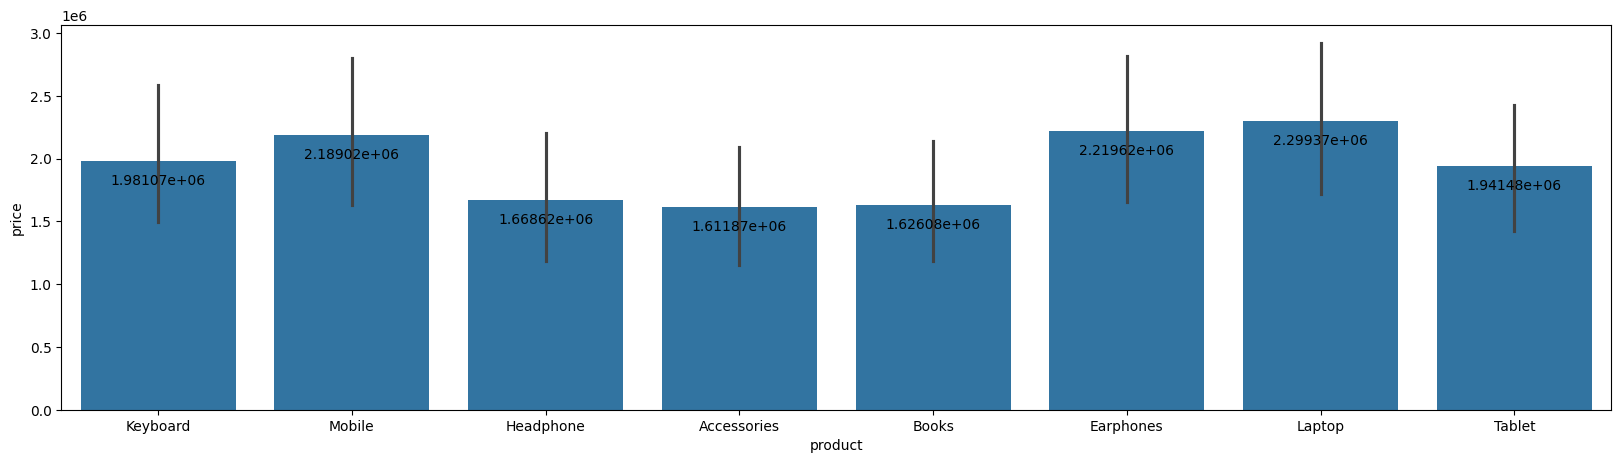

In [391]:
plt.figure(figsize = (20,5))
c = sns.barplot(data = df, x = 'product', y = 'price', estimator = sum)
c.bar_label(c.containers[0], padding = -19)
plt.show()

laptop made highest revenue

# q2

In [392]:
df['discount'].unique()

array(['flat 10%', 'upto 30%', 'flat 20%', 'flat 15%'], dtype=object)

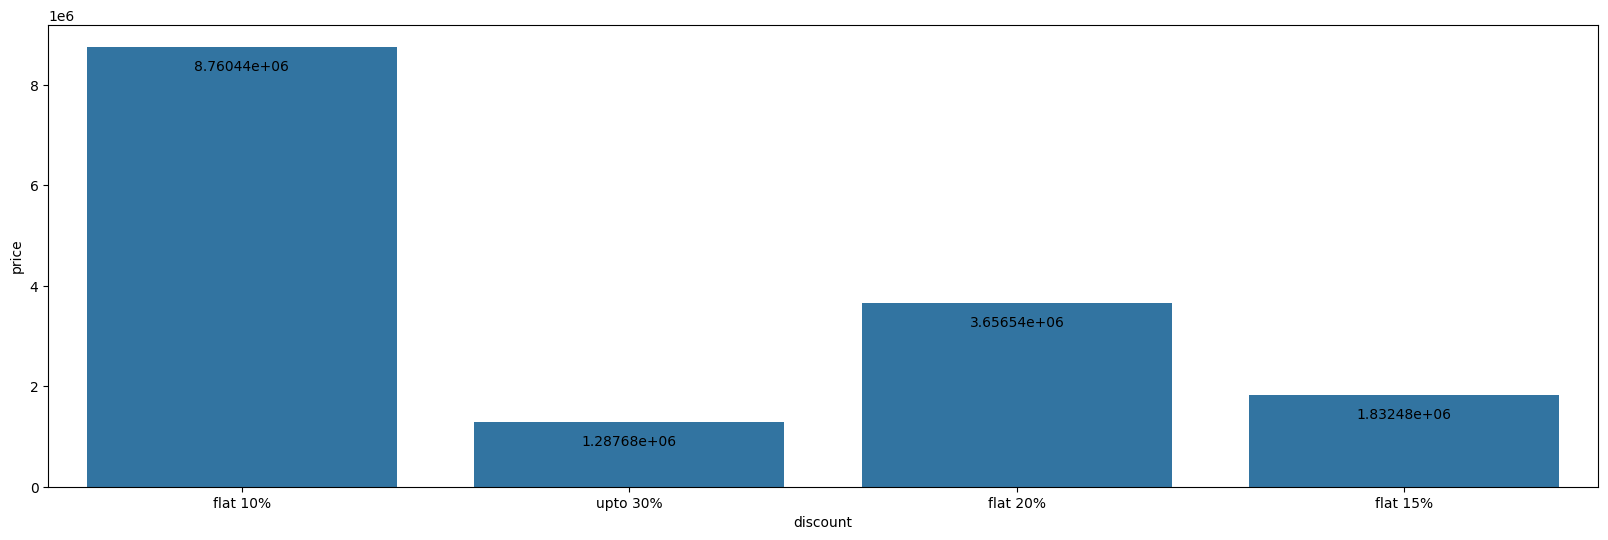

In [393]:
plt.figure(figsize = (20,6))
c = sns.barplot(data = df, x = 'discount', y = 'price', estimator = sum, errorbar = None)
c.bar_label(c.containers[0], padding = -19)
plt.show()

the plot show discount doesnt affect the sales or revenue

# q3

In [394]:
cols = ['Amazon','Flipkart']
melted = pd.melt(df, id_vars = 'product', value_vars = df[cols], var_name = 'Application', value_name = 'availability')
melted

,product,Application,availability
0,Keyboard,Amazon,0
1,Mobile,Amazon,0
2,Headphone,Amazon,1
3,Accessories,Amazon,1
4,Books,Amazon,0
...,...,...,...
1995,Keyboard,Flipkart,1
1996,Tablet,Flipkart,1
1997,Tablet,Flipkart,0
1998,Books,Flipkart,1


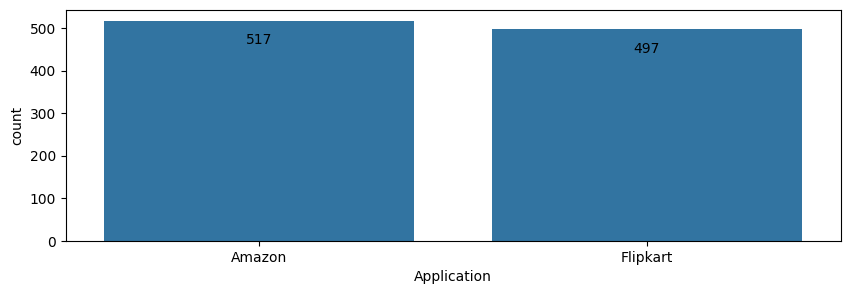

In [395]:
new_d = melted.loc[melted['availability']==1, ['Application','availability']]
plt.figure(figsize = (10,3))
c = sns.countplot(new_d, x = 'Application')
c.bar_label(c.containers[0], padding = -19)
plt.show()

amazon has more number of product  

# q4

# q5

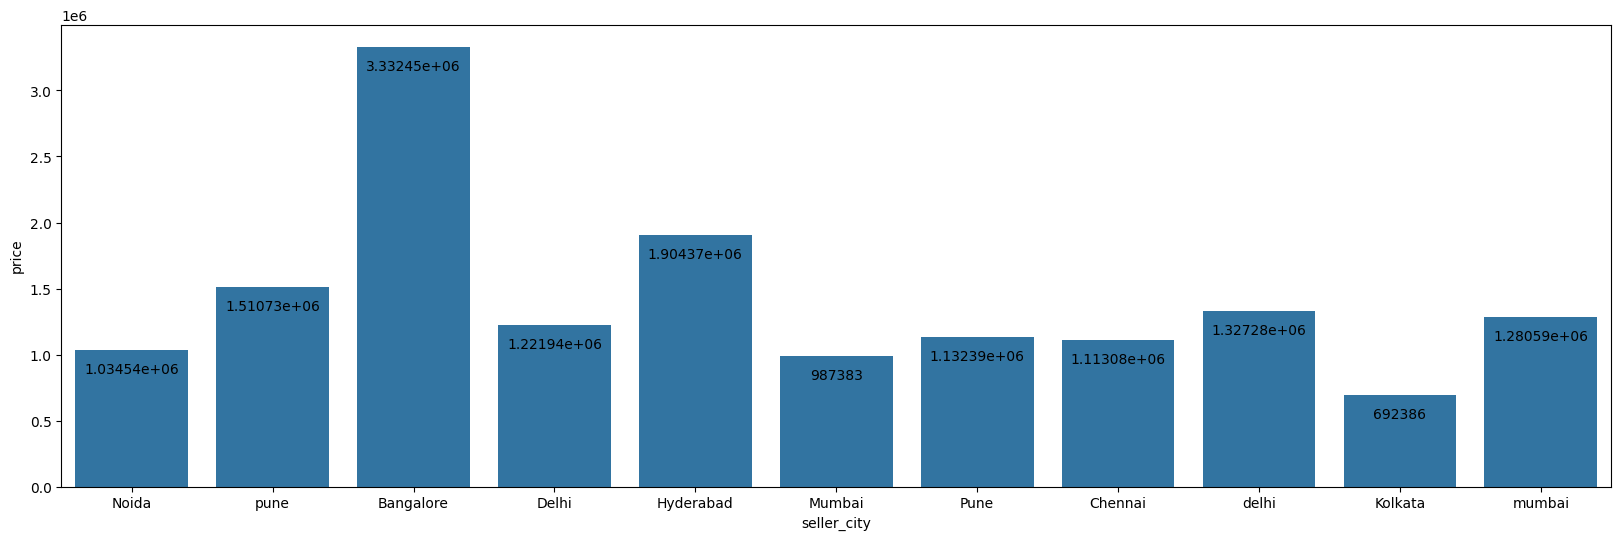

In [396]:
plt.figure(figsize = (20,6))
c = sns.barplot(data = df, x = 'seller_city', y = 'price', estimator = sum, errorbar = None)
c.bar_label(c.containers[0], padding = -19)
plt.show()

banglore city has more number online sales

# q6

In [397]:
df[['temp','Discount in %']] = (df['discount'].str.strip('%')).str.split(' ', expand = True)
df = df.drop(columns = ['temp','discount'])

In [398]:
df['Discount in %'] = df['Discount in %'].astype('Int64')

In [399]:
df['final price'] = df['price'] - (df['price'] * df['Discount in %'] // 100)
df.head()

,id,product,price,brand_model,Amazon,Flipkart,rating,stock,seller_city,warranty,Discount in %,final price
0,1,Keyboard,70000,Dell-D11,0,1,3.8,Yes,Noida,12 months,10,63000
1,2,Mobile,80000,Logitech K120,0,1,<bound method Series.mean of 0 3.8\n1 ...,No,pune,12 months,10,72000
2,3,Headphone,8900,Classmate,1,0,4.5,Y,Bangalore,12 months,10,8010
3,4,Accessories,1299,Dell-D11,1,0,3.0,Yes,Delhi,12 months,10,1170
4,5,Books,899,Classmate,0,0,4.5,Y,Noida,12 months,10,810


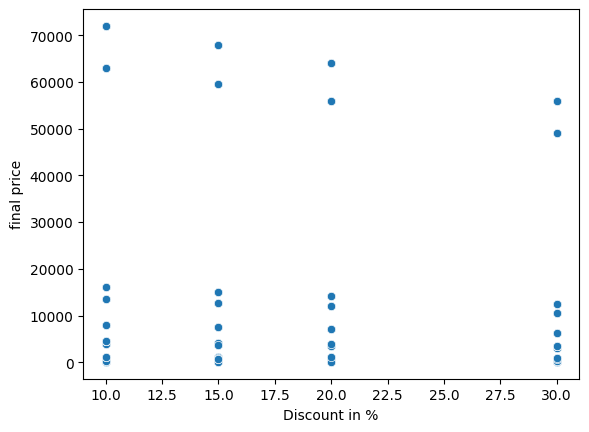

In [400]:
sns.scatterplot(data = df, x = 'Discount in %', y = 'final price')
plt.show()

final price and discount is inversly proppotinal so that discount incraeses final price reduces

TypeError: float() argument must be a string or a real number, not 'method'

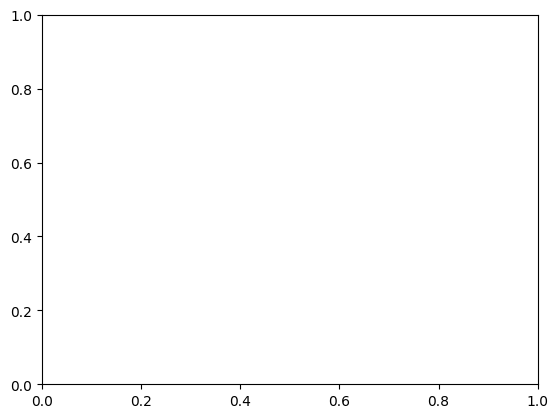

In [402]:
plt.scatter(df['final price'],df['rating'])
plt.xlabel("price inr" )
plt.ylabel('rating')
plt.show()

# q7

In [ ]:
cols = ['Amazon','Flipkart']
melted = pd.melt(df, id_vars = 'brand_model', value_vars = df[cols], var_name = 'Application', value_name = 'availability')
melted

,brand_model,Application,availability
0,Dell-D11,Amazon,0
1,Logitech K120,Amazon,0
2,Classmate,Amazon,1
3,Dell-D11,Amazon,1
4,Classmate,Amazon,0
...,...,...,...
1995,Samsung S12,Flipkart,1
1996,Boat-B19,Flipkart,1
1997,Lenovo L11,Flipkart,0
1998,Classmate,Flipkart,1


In [ ]:
avblty_df = melted.loc[melted['availability'] == 1, ['brand_model','Application','availability']]

In [ ]:
avblty_df.loc[avblty_df['Application']=='Amazon','brand_model'].unique()

array(['Classmate', 'Dell-D11', 'Samsung S12', 'Logitech K120',
       'Acer Aspire 5', 'Boat-B19', 'Jbl_450Bt', 'Mi-Cable',
       'Lenovo Tab M10', 'Boat-B11', 'Vivo V1', 'Lenovo L11', 'Hp-H01',
       'Apple-13'], dtype=object)

In [ ]:
avblty_df.loc[avblty_df['Application']=='Flipkart','brand_model'].unique()

array(['Dell-D11', 'Logitech K120', 'Samsung S12', 'Vivo V1',
       'Lenovo Tab M10', 'Boat-B19', 'Acer Aspire 5', 'Jbl_450Bt',
       'Mi-Cable', 'Hp-H01', 'Classmate', 'Lenovo L11', 'Apple-13',
       'Boat-B11'], dtype=object)

 Dell-D11, Logitech K120, Samsung S12, Vivo V1,
       Lenovo Tab M10, Boat-B19, Acer Aspire 5, Jbl_450Bt,
       Mi-Cable, Hp-H01, Classmate, Lenovo L11, Apple-13,
       Boat-B11 these brands are available on both Amazon and Flipkart.

# q8

- Cities like Chennai, Kolkata, Noida are contributing less to the online sales, so focus on sales in those cities.
- Flipkart has less product coverage, so Flipkart can bring more products to their platform.


# q9


- Categories like Accessories, books and headphones contributes very less to the revenue, So focus on those product categories.
- Bring more discounts to the cities which are contributing less to the total revenue like chennai, kolkata and noida.